# 📈 SMA & EMA Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize two of the most widely used moving average indicators in technical analysis:

- **Simple Moving Average (SMA)**
- **Exponential Moving Average (EMA)**

We also generate signals based on **SMA crossover rules** and visualize them on price charts.  
The code can run on **synthetic price data** (offline) or **real financial data** from Yahoo Finance.

---

## 🔹 Technical Background

### Simple Moving Average (SMA)
\[
SMA_n = \frac{P_t + P_{t-1} + \dots + P_{t-n+1}}{n}
\]  
- Smooths price movements.  
- Shows overall trend direction.  

### Exponential Moving Average (EMA)
\[
EMA_t = \alpha P_t + (1-\alpha) EMA_{t-1}, \quad \alpha = \frac{2}{n+1}
\]  
- Weights recent prices more heavily.  
- Reacts faster to price changes.  

### Crossover Strategy
- **Buy Signal** → Fast SMA crosses above Slow SMA.  
- **Sell Signal** → Fast SMA crosses below Slow SMA.  



In [4]:
print("Hello World!")

Hello World!


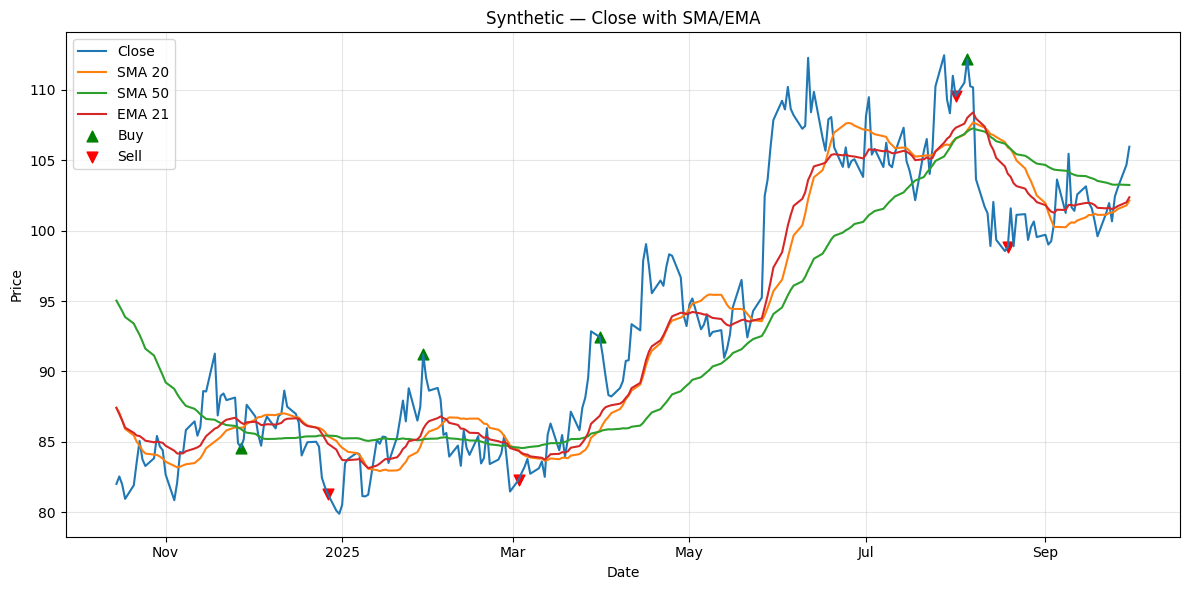

Mode: Synthetic
Rows: 251
Last Close: 105.95
Last SMA20: 102.13
Last SMA50: 103.24
Last EMA21: 102.36
Signals — Buys: 4 Sells: 4


In [7]:
# ==== SMA & EMA — minimal, robust, runs out of the box ====
# Default uses synthetic data (no internet needed). Switch RUN_MODE="yfinance" to use real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------ CONFIG ------------------
RUN_MODE   = "synthetic"   # "synthetic" (guaranteed) or "yfinance"
TICKER     = "AAPL"        # used only when RUN_MODE="yfinance"
PERIOD_DAYS= 300           # length for synthetic series (business days)

SMA_FAST = 20
SMA_SLOW = 50
EMA_LEN  = 21
# --------------------------------------------

# 1) LOAD DATA
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period="1y", interval="1d", auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("Download returned no data.")
        close = pd.to_numeric(df["Close"], errors="coerce").dropna()
        title = f"{TICKER} — Close with SMA/EMA"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=PERIOD_DAYS)
    mu, sigma, dt = 0.12, 0.30, 1/252  # GBM parameters
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    title = "Synthetic — Close with SMA/EMA"

# 2) INDICATORS
sma_fast = close.rolling(SMA_FAST, min_periods=SMA_FAST).mean()
sma_slow = close.rolling(SMA_SLOW, min_periods=SMA_SLOW).mean()
ema      = close.ewm(span=EMA_LEN, adjust=False).mean()

dfp = pd.concat([close, sma_fast, sma_slow, ema], axis=1)
dfp.columns = ["Close", f"SMA{SMA_FAST}", f"SMA{SMA_SLOW}", f"EMA{EMA_LEN}"]
dfp = dfp.dropna()

# 3) SIMPLE CROSSOVER SIGNALS
buy  = (dfp[f"SMA{SMA_FAST}"].shift(1) <= dfp[f"SMA{SMA_SLOW}"].shift(1)) & (dfp[f"SMA{SMA_FAST}"] > dfp[f"SMA{SMA_SLOW}"])
sell = (dfp[f"SMA{SMA_FAST}"].shift(1) >= dfp[f"SMA{SMA_SLOW}"].shift(1)) & (dfp[f"SMA{SMA_SLOW}"] > dfp[f"SMA{SMA_FAST}"])
buy_idx  = dfp.index[buy.fillna(False)]
sell_idx = dfp.index[sell.fillna(False)]

# 4) PLOT
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(dfp.index, dfp["Close"], label="Close")
ax.plot(dfp.index, dfp[f"SMA{SMA_FAST}"], label=f"SMA {SMA_FAST}")
ax.plot(dfp.index, dfp[f"SMA{SMA_SLOW}"], label=f"SMA {SMA_SLOW}")
ax.plot(dfp.index, dfp[f"EMA{EMA_LEN}"], label=f"EMA {EMA_LEN}")
ax.scatter(buy_idx,  dfp.loc[buy_idx, "Close"],  marker="^", s=60, color="green", label="Buy")
ax.scatter(sell_idx, dfp.loc[sell_idx,"Close"], marker="v", s=60, color="red",   label="Sell")

ax.set_title(title)
ax.set_xlabel("Date"); ax.set_ylabel("Price")
ax.grid(True, alpha=0.3); ax.legend()
locator = mdates.AutoDateLocator(); formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
plt.tight_layout(); plt.show()

# 5) SUMMARY
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(dfp))
print("Last Close:", round(dfp['Close'].iloc[-1], 2))
print(f"Last SMA{SMA_FAST}:", round(dfp[f'SMA{SMA_FAST}'].iloc[-1], 2))
print(f"Last SMA{SMA_SLOW}:", round(dfp[f'SMA{SMA_SLOW}'].iloc[-1], 2))
print(f"Last EMA{EMA_LEN}:",  round(dfp[f'EMA{EMA_LEN}'].iloc[-1], 2))
print("Signals — Buys:", int(buy.sum()), "Sells:", int(sell.sum()))
